In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv("results_herbivore.csv", sep=';', decimal=',')

df = df[df['Generation'] >= 1].copy()

In [2]:
reset_idx = df[df['Generation'].diff() < 0].index
if len(reset_idx) > 0:
    first_run = df.loc[:reset_idx[0]-1].copy()
else:
    first_run = df.copy()

In [3]:
avg_columns = [col for col in first_run.columns if col.startswith("AvgFitness")]

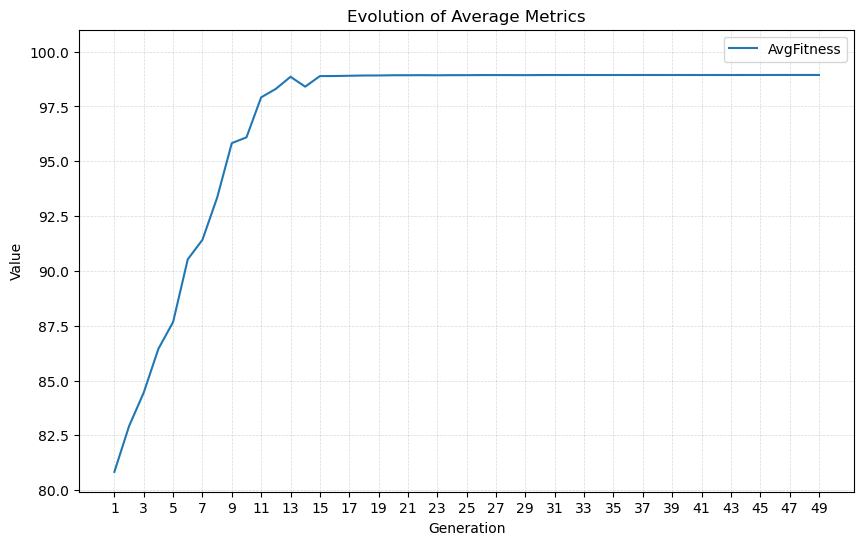

In [4]:
plt.figure(figsize=(10, 6))

line_styles = ['-', '--', '-.']

for i, col in enumerate(avg_columns):
    plt.plot(
        first_run['Generation'],
        first_run[col],
        linestyle=line_styles[i % len(line_styles)],
        label=col
    )

plt.xlabel("Generation")
plt.ylabel("Value")
plt.title("Evolution of Average Metrics")

# Верхняя граница Y жестко, нижняя автоматическая
plt.ylim(bottom=None, top=101)

# Сетка Y
y_min = first_run[avg_columns].min().min()
y_ticks = np.arange(np.floor(y_min), 101, 2.5)
plt.yticks(y_ticks)
plt.grid(axis='y', color='gray', linestyle='--', linewidth=0.5, alpha=0.3)

# --- Динамические деления по X ---
x_min = first_run['Generation'].min()
x_max = first_run['Generation'].max()

# Шаг делений по X
if x_max <= 50:
    step = 2
elif x_max <= 100:
    step = 4
elif x_max <= 200:
    step = 8
else:
    step = max(1, int(x_max * 0.1))

x_ticks = np.arange(x_min, x_max + 1, step)
plt.xticks(x_ticks)
plt.grid(axis='x', color='gray', linestyle='--', linewidth=0.5, alpha=0.3)

plt.legend()
plt.show()